# Vietnamese Sentiment Analysis: FastText and PhoBERT

Notebook nay duoc viet lai de chay on dinh theo thu tu cell.

- Phan 1: EDA va tien xu ly
- Phan 2: FastText baseline (train truc tiep)
- Phan 3: PhoBERT su dung checkpoint da fine-tune san (`phobert-tune-c`)

Mac dinh `FAST_RUN = False` de giu du lieu day du khi danh gia.

Sau khi chay cell cai dat thu vien, can restart kernel roi moi chay tiep.


In [17]:
!pip install -U "numpy<2" "transformers==4.39.3" "accelerate==0.29.2" "datasets==2.18.0" underthesea fasttext-wheel seaborn safetensors -q


[notice] A new release of pip is available: 25.0.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [18]:
import json
import os
import random
import re
from collections import Counter
from pathlib import Path

import fasttext
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import torch
from datasets import Dataset
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, precision_recall_fscore_support
from sklearn.model_selection import train_test_split
from transformers import AutoModelForSequenceClassification, AutoTokenizer, DataCollatorWithPadding, Trainer, TrainingArguments, pipeline
from underthesea import word_tokenize

In [19]:
def find_project_root() -> Path:
    candidates = [Path.cwd(), Path.cwd().parent, Path.cwd().parent.parent]
    for candidate in candidates:
        if (candidate / "resources").exists() and (candidate / "data").exists():
            return candidate.resolve()
    raise FileNotFoundError("Khong tim thay root cua project.")


PROJECT_ROOT = find_project_root()
os.chdir(PROJECT_ROOT)

RAW_TRAIN_PATH = PROJECT_ROOT / "data" / "preprocessed" / "train.csv"
RAW_TEST_PATH = PROJECT_ROOT / "data" / "preprocessed" / "test.csv"
RESOURCES_DIR = PROJECT_ROOT / "resources"
PROCESSED_DIR = PROJECT_ROOT / "data" / "processed"
OUTPUTS_DIR = PROJECT_ROOT / "outputs"
PHOBERT_OUTPUT_DIR = OUTPUTS_DIR / "phobert-sentiment"
PHOBERT_SAVED_DIR = OUTPUTS_DIR / "phobert-tune-c"
FASTTEXT_OUTPUT_DIR = OUTPUTS_DIR / "fasttext"

PROCESSED_DIR.mkdir(parents=True, exist_ok=True)
PHOBERT_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
FASTTEXT_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print("Project root:", PROJECT_ROOT)
print("CUDA available:", torch.cuda.is_available())


Project root: C:\Users\leanh\OneDrive\Documents\New project 2
CUDA available: True


In [20]:
SEED = 42
MODEL_NAME = "vinai/phobert-base"
LABEL_ID_TO_NAME = {0: "negative", 1: "neutral", 2: "positive"}
LABEL_NAME_TO_ID = {value: key for key, value in LABEL_ID_TO_NAME.items()}
LABEL_DISPLAY = {0: "Negative", 1: "Neutral", 2: "Positive"}

FAST_RUN = False

PHOBERT_MAX_LENGTH = 128
PHOBERT_BATCH_SIZE = 16
PHOBERT_EVAL_BATCH_SIZE = 16

FASTTEXT_LR = 0.5
FASTTEXT_EPOCHS = 10 if FAST_RUN else 25
FASTTEXT_WORD_NGRAMS = 2
FASTTEXT_DIM = 100

PHOBERT_SAMPLE_SIZES = {
    "train": 900,
    "val": 180,
    "test": 180,
}

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)


# EDA and Preprocessing

In [21]:
with open(RESOURCES_DIR / "teencode.json", "r", encoding="utf-8") as f:
    TEENCODE_DICT = json.load(f)

with open(RESOURCES_DIR / "stopword.json", "r", encoding="utf-8") as f:
    stopword_data = json.load(f)

STOPWORDS = set(stopword_data["remove_always"]) - set(stopword_data["keep_for_sentiment"])


def clean_and_tokenize(text):
    if not isinstance(text, str):
        return []
    text = text.lower()
    text = re.sub(r"[^\w\s]", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    words = [TEENCODE_DICT.get(word, word) for word in text.split()]
    segmented = word_tokenize(" ".join(words), format="text")
    return [word for word in segmented.split() if word not in STOPWORDS]


def clean_text(text):
    return " ".join(clean_and_tokenize(text))


def save_fasttext_format(dataframe, output_path):
    lines = "__label__" + dataframe["flag"].astype(str) + " " + dataframe["comments_clean"].astype(str)
    lines.to_csv(output_path, index=False, header=False, encoding="utf-8")

In [22]:
df = pd.read_csv(RAW_TRAIN_PATH)
df_test_external = pd.read_csv(RAW_TEST_PATH)

df = df.dropna(subset=["comments", "flag"])
df_test_external = df_test_external.dropna(subset=["comments", "flag"])

df["tokens"] = df["comments"].apply(clean_and_tokenize)
df["comments_clean"] = df["tokens"].apply(lambda tokens: " ".join(tokens))
df["length"] = df["tokens"].apply(len)

df_test_external["comments_clean"] = df_test_external["comments"].apply(clean_text)
df = df[df["comments_clean"].str.strip() != ""].copy()
df_test_external = df_test_external[df_test_external["comments_clean"].str.strip() != ""].copy()

print(df.head())
print("Train shape:", df.shape)
print("External test shape:", df_test_external.shape)
print(df["flag"].value_counts().sort_index())

                                            comments  flag  \
0  Bia ở đây nhiều vị cho mình chọn có rất nhiều ...     2   
1  Đồ ăn quá chán đc dăm ba miếng thịt đậu khô kh...     0   
2                                       áo mặc thích     1   
3  Bò bía chú này không ngon đâu ít đồ ăn lắm toà...     0   
4                         mấy bố ơi cái đó hook thôi     1   

                                              tokens  \
0  [bia, ở, vị, chọn, có, rất, bia, thủ_công, để,...   
1  [đồ_ăn, quá, chán, đc, dăm_ba, miếng, thịt, đậ...   
2                                   [áo, mặc, thích]   
3  [bò, bía, chú, không, ngon, đâu, đồ_ăn, lắm, t...   
4                                [mấy, bố, ơi, hook]   

                                      comments_clean  length  
0  bia ở vị chọn có rất bia thủ_công để lại ấn_tư...      55  
1  đồ_ăn quá chán đc dăm_ba miếng thịt đậu khô kh...      22  
2                                       áo mặc thích       3  
3  bò bía chú không ngon đâu đồ_ăn lắm

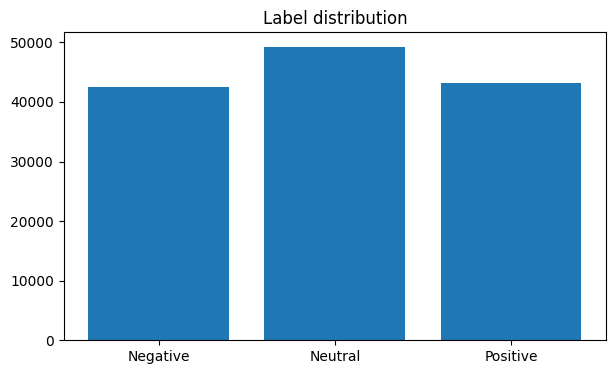

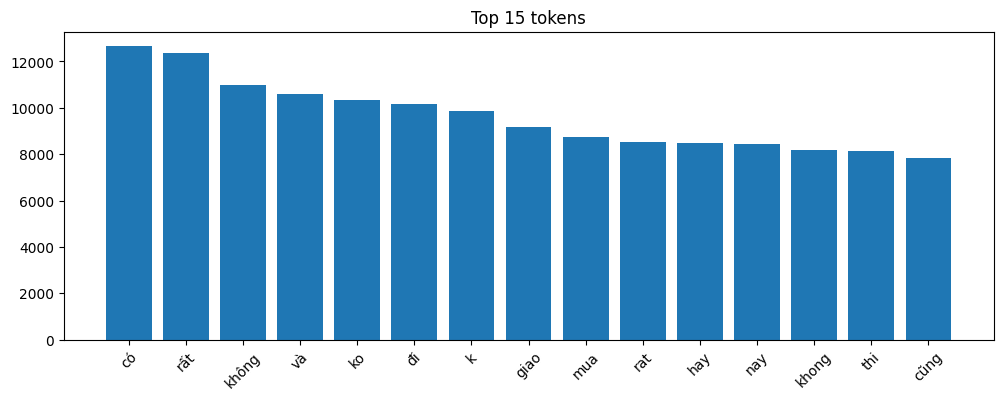

In [23]:
all_words = [word for tokens in df["tokens"] for word in tokens]
label_counts = df["flag"].value_counts().sort_index()

plt.figure(figsize=(7, 4))
plt.bar([LABEL_DISPLAY[i] for i in label_counts.index], label_counts.values)
plt.title("Label distribution")
plt.show()

top_15 = Counter(all_words).most_common(15)
words, freqs = zip(*top_15)
plt.figure(figsize=(12, 4))
plt.bar(words, freqs)
plt.xticks(rotation=45)
plt.title("Top 15 tokens")
plt.show()

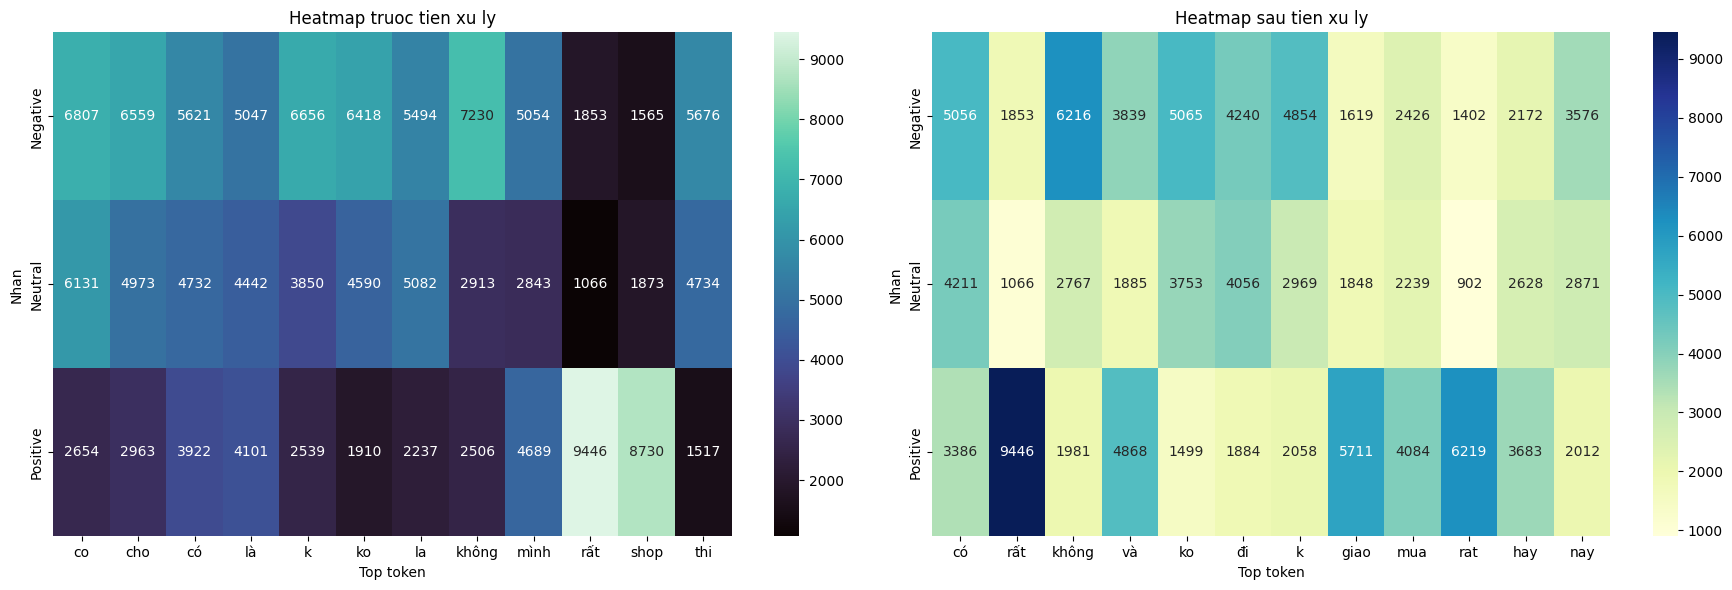

In [24]:
def build_label_token_heatmap(dataframe, text_column, top_k=12):
    rows = []
    all_tokens = []
    for label_id in sorted(LABEL_DISPLAY.keys()):
        label_text = dataframe.loc[dataframe['flag'] == label_id, text_column].dropna().astype(str)
        tokens = ' '.join(label_text.tolist()).split()
        rows.append(Counter(tokens))
        all_tokens.extend(tokens)

    top_tokens = [token for token, _ in Counter(all_tokens).most_common(top_k)]
    heatmap_df = pd.DataFrame(0, index=[LABEL_DISPLAY[i] for i in sorted(LABEL_DISPLAY.keys())], columns=top_tokens)

    for idx, label_id in enumerate(sorted(LABEL_DISPLAY.keys())):
        for token in top_tokens:
            heatmap_df.loc[LABEL_DISPLAY[label_id], token] = rows[idx].get(token, 0)

    return heatmap_df

before_heatmap = build_label_token_heatmap(df.assign(raw_comments=df['comments'].astype(str).str.lower()), 'raw_comments', top_k=12)
after_heatmap = build_label_token_heatmap(df, 'comments_clean', top_k=12)

fig, axes = plt.subplots(1, 2, figsize=(18, 6))
sns.heatmap(before_heatmap, cmap='mako', annot=True, fmt='d', ax=axes[0])
axes[0].set_title('Heatmap truoc tien xu ly')
axes[0].set_xlabel('Top token')
axes[0].set_ylabel('Nhan')

sns.heatmap(after_heatmap, cmap='YlGnBu', annot=True, fmt='d', ax=axes[1])
axes[1].set_title('Heatmap sau tien xu ly')
axes[1].set_xlabel('Top token')
axes[1].set_ylabel('Nhan')

plt.tight_layout()
plt.show()


# General train_test_split

In [25]:
train_df, test_df = train_test_split(df, test_size=0.2, random_state=SEED, stratify=df["flag"])
train_df, val_df = train_test_split(train_df, test_size=0.1, random_state=SEED, stratify=train_df["flag"])

print(train_df.shape, val_df.shape, test_df.shape)
print(train_df["flag"].value_counts().sort_index())

(97173, 5) (10798, 5) (26993, 5)
flag
0    30591
1    35441
2    31141
Name: count, dtype: int64


# FastText

In [26]:
train_fasttext_df = train_df[["comments_clean", "flag"]]
val_fasttext_df = val_df[["comments_clean", "flag"]]
test_fasttext_df = test_df[["comments_clean", "flag"]]

train_fasttext_path = PROCESSED_DIR / "train_fasttext.txt"
val_fasttext_path = PROCESSED_DIR / "val_fasttext.txt"
test_fasttext_path = PROCESSED_DIR / "test_fasttext.txt"

save_fasttext_format(train_fasttext_df, train_fasttext_path)
save_fasttext_format(val_fasttext_df, val_fasttext_path)
save_fasttext_format(test_fasttext_df, test_fasttext_path)

train_fasttext_df.to_csv(PROCESSED_DIR / "train_new_cleaned.csv", index=False, encoding="utf-8-sig")
val_fasttext_df.to_csv(PROCESSED_DIR / "val_cleaned.csv", index=False, encoding="utf-8-sig")
test_fasttext_df.to_csv(PROCESSED_DIR / "test_cleaned.csv", index=False, encoding="utf-8-sig")

print(train_fasttext_df.shape, val_fasttext_df.shape, test_fasttext_df.shape)

(97173, 2) (10798, 2) (26993, 2)


In [34]:
fasttext_model = fasttext.train_supervised(
    input=str(train_fasttext_path),
    autotuneValidationFile=str(val_fasttext_path),
    autotuneDuration=600,
    loss="softmax"
)

y_true_fasttext = test_fasttext_df["flag"].reset_index(drop=True).tolist()
y_pred_fasttext = []

for text in test_fasttext_df["comments_clean"].reset_index(drop=True).tolist():
    labels, probs = fasttext_predict_compat(fasttext_model, text)
    y_pred_fasttext.append(parse_fasttext_label(labels[0]))

print(classification_report(
    y_true_fasttext,
    y_pred_fasttext,
    target_names=["Negative", "Neutral", "Positive"]
))

fasttext_model.save_model(str(FASTTEXT_OUTPUT_DIR / "fasttext_sentiment.bin"))

              precision    recall  f1-score   support

    Negative       0.77      0.83      0.79      8497
     Neutral       0.78      0.64      0.70      9845
    Positive       0.76      0.85      0.81      8651

    accuracy                           0.77     26993
   macro avg       0.77      0.77      0.77     26993
weighted avg       0.77      0.77      0.76     26993



FastText Accuracy: 0.7680
FastText Precision: 0.7689
FastText Recall: 0.7680
FastText F1-score: 0.7650


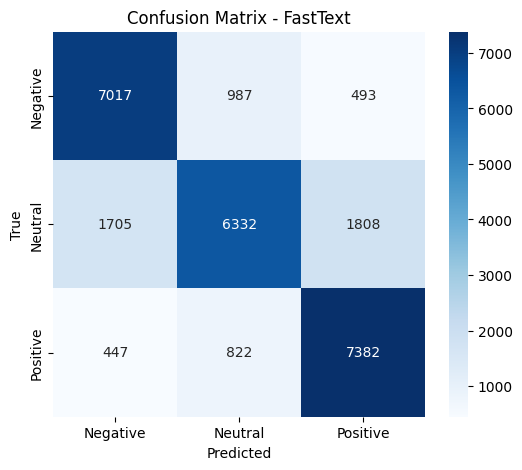

In [35]:
accuracy = accuracy_score(y_true_fasttext, y_pred_fasttext)
precision, recall, f1, _ = precision_recall_fscore_support(y_true_fasttext, y_pred_fasttext, average="weighted")
cm = confusion_matrix(y_true_fasttext, y_pred_fasttext)

print(f"FastText Accuracy: {accuracy:.4f}")
print(f"FastText Precision: {precision:.4f}")
print(f"FastText Recall: {recall:.4f}")
print(f"FastText F1-score: {f1:.4f}")

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=[LABEL_DISPLAY[i] for i in range(3)], yticklabels=[LABEL_DISPLAY[i] for i in range(3)])
plt.title("Confusion Matrix - FastText")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()

# PhoBERT

In [29]:
def sample_per_label(dataframe, total_size):
    per_label = max(1, total_size // len(LABEL_ID_TO_NAME))
    parts = []
    for label_id in sorted(LABEL_ID_TO_NAME.keys()):
        part = dataframe[dataframe["flag"] == label_id]
        parts.append(part.sample(n=min(len(part), per_label), random_state=SEED))
    return pd.concat(parts, axis=0).sample(frac=1.0, random_state=SEED).reset_index(drop=True)

if FAST_RUN:
    phobert_train_df = sample_per_label(train_df, PHOBERT_SAMPLE_SIZES["train"])
    phobert_val_df = sample_per_label(val_df, PHOBERT_SAMPLE_SIZES["val"])
    phobert_test_df = sample_per_label(test_df, PHOBERT_SAMPLE_SIZES["test"])
else:
    phobert_train_df = train_df
    phobert_val_df = val_df
    phobert_test_df = test_df

print(phobert_train_df.shape, phobert_val_df.shape, phobert_test_df.shape)
print(phobert_train_df["flag"].value_counts().sort_index())

(97173, 5) (10798, 5) (26993, 5)
flag
0    30591
1    35441
2    31141
Name: count, dtype: int64


In [30]:
train_dataset = Dataset.from_pandas(phobert_train_df[["comments_clean", "flag"]].rename(columns={"flag": "labels"}), preserve_index=False)
val_dataset = Dataset.from_pandas(phobert_val_df[["comments_clean", "flag"]].rename(columns={"flag": "labels"}), preserve_index=False)
test_dataset = Dataset.from_pandas(phobert_test_df[["comments_clean", "flag"]].rename(columns={"flag": "labels"}), preserve_index=False)

print("Su dung checkpoint PhoBERT da fine-tune san tai:", PHOBERT_SAVED_DIR)
tokenizer = AutoTokenizer.from_pretrained(str(PHOBERT_SAVED_DIR), use_fast=False)
model = AutoModelForSequenceClassification.from_pretrained(str(PHOBERT_SAVED_DIR))
model.config.id2label = LABEL_ID_TO_NAME
model.config.label2id = LABEL_NAME_TO_ID

def preprocess_function(examples):
    texts = [str(x).strip() for x in examples["comments_clean"]]
    return tokenizer(texts, truncation=True, max_length=PHOBERT_MAX_LENGTH)

tokenized_val = val_dataset.map(preprocess_function, batched=True)
tokenized_test = test_dataset.map(preprocess_function, batched=True)

data_collator = DataCollatorWithPadding(tokenizer=tokenizer)
print(tokenized_test[0])


Su dung checkpoint PhoBERT da fine-tune san tai: C:\Users\leanh\OneDrive\Documents\New project 2\outputs\phobert-tune-c


Map: 100%|██████████| 26993/26993 [00:02<00:00, 9404.80 examples/s] 

{'comments_clean': 'may nhu_con dieng', 'labels': 0, 'input_ids': [0, 1800, 45508, 73, 3173, 16030, 2], 'token_type_ids': [0, 0, 0, 0, 0, 0, 0], 'attention_mask': [1, 1, 1, 1, 1, 1, 1]}


In [31]:
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    predictions = np.argmax(logits, axis=-1)
    accuracy = accuracy_score(labels, predictions)
    precision, recall, weighted_f1, _ = precision_recall_fscore_support(labels, predictions, average="weighted")
    macro_f1 = precision_recall_fscore_support(labels, predictions, average="macro")[2]
    return {
        "accuracy": accuracy,
        "precision": precision,
        "recall": recall,
        "weighted_f1": weighted_f1,
        "macro_f1": macro_f1,
    }

eval_args = TrainingArguments(
    output_dir=str(PHOBERT_OUTPUT_DIR),
    per_device_eval_batch_size=PHOBERT_EVAL_BATCH_SIZE,
    report_to="none",
    seed=SEED,
)

trainer = Trainer(
    model=model,
    args=eval_args,
    eval_dataset=tokenized_val,
    compute_metrics=compute_metrics,
    data_collator=data_collator,
)

val_metrics = trainer.evaluate(tokenized_val)
print("Validation metrics from saved PhoBERT model:")
for key, value in val_metrics.items():
    if isinstance(value, (int, float)):
        print(f"{key}: {value}")


c:\Users\leanh\AppData\Local\Programs\Python\Python312\Lib\site-packages\accelerate\accelerator.py:436: FutureWarning: Passing the following arguments to `Accelerator` is deprecated and will be removed in version 1.0 of Accelerate: dict_keys(['dispatch_batches', 'split_batches', 'even_batches', 'use_seedable_sampler']). Please pass an `accelerate.DataLoaderConfiguration` instead: 
dataloader_config = DataLoaderConfiguration(dispatch_batches=None, split_batches=False, even_batches=True, use_seedable_sampler=True)
  warnings.warn(
100%|██████████| 675/675 [00:56<00:00, 11.90it/s]

Validation metrics from saved PhoBERT model:
eval_loss: 0.533940851688385
eval_accuracy: 0.7982033709946287
eval_precision: 0.7977898454947382
eval_recall: 0.7982033709946287
eval_weighted_f1: 0.7977980830269276
eval_macro_f1: 0.8001432808162153
eval_runtime: 56.7661
eval_samples_per_second: 190.219
eval_steps_per_second: 11.891


100%|██████████| 1688/1688 [02:25<00:00, 11.62it/s]


              precision    recall  f1-score   support

    Negative       0.82      0.80      0.81      8497
     Neutral       0.75      0.73      0.74      9845
    Positive       0.81      0.85      0.83      8651

    accuracy                           0.79     26993
   macro avg       0.79      0.79      0.79     26993
weighted avg       0.79      0.79      0.79     26993



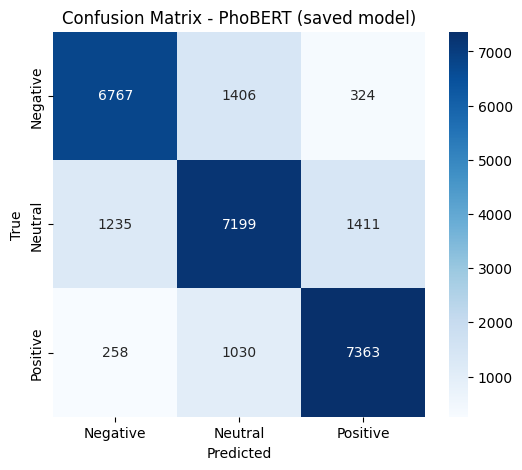

In [32]:
predictions_output = trainer.predict(tokenized_test)
y_pred_phobert = np.argmax(predictions_output.predictions, axis=1)
y_true_phobert = np.array(tokenized_test["labels"])

print(classification_report(y_true_phobert, y_pred_phobert, target_names=["Negative", "Neutral", "Positive"]))

cm = confusion_matrix(y_true_phobert, y_pred_phobert)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=[LABEL_DISPLAY[i] for i in range(3)], yticklabels=[LABEL_DISPLAY[i] for i in range(3)])
plt.title("Confusion Matrix - PhoBERT (saved model)")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()


In [33]:
clf = pipeline("text-classification", model=str(PHOBERT_SAVED_DIR), tokenizer=str(PHOBERT_SAVED_DIR), truncation=True)

def predict_fasttext(text):
    cleaned = clean_text(text)
    labels, probs = fasttext_predict_compat(fasttext_model, cleaned)
    return {
        "cleaned": cleaned,
        "label": LABEL_DISPLAY[parse_fasttext_label(labels[0])],
        "score": float(probs[0]),
    }


def predict_phobert(text):
    cleaned = clean_text(text)
    result = clf(cleaned)[0]
    return {
        "cleaned": cleaned,
        "label": LABEL_DISPLAY[LABEL_NAME_TO_ID[result["label"]]],
        "score": result["score"],
    }


sample_text = "quan an nay kha on, phuc vu nhanh va lich su"
print("FastText:", predict_fasttext(sample_text))
print("PhoBERT:", predict_phobert(sample_text))


FastText: {'cleaned': 'quan an nay kha_on phuc vu nhanh va lich_su', 'label': 'Positive', 'score': 0.9789008498191833}
PhoBERT: {'cleaned': 'quan an nay kha_on phuc vu nhanh va lich_su', 'label': 'Neutral', 'score': 0.7588433623313904}
